In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from scipy import ndimage
import os
import sys
from scipy.interpolate import interp1d
import corner
from radmc3dPy import image
from radmc3dPy.analyze import *
# from CB68.data_dict import data_dict
from make_conti import generate_model
sys.path.append("..")
from profile_radial.make_disk import generate_disk

In [16]:
sizeau = 80
npix = 500
pixel_area = (sizeau/npix/140)**2
beam_axis = [0.0363, 0.0274]
beam_area = beam_axis[0]*beam_axis[1]*np.pi/(4*np.log(2))
r_axis = np.linspace(-(sizeau//2), sizeau//2, npix, endpoint=True)

In [17]:
edisk_radial = np.load("edisk_radial.npz")
i_r_obs = edisk_radial["i_r"]

In [18]:
def rotate_image(image, posang):
  if isinstance(image, np.ndarray)!=True:
    image.imageJyppix= ndimage.rotate(image.imageJyppix, posang, reshape=False, axes=(1, 0))
    image.imageJyppix = np.nan_to_num(image.imageJyppix, nan=0)
    return image.imageJyppix[:,:,0]
  else:
    image = ndimage.rotate(image, posang, reshape=False, axes=(1, 0))
    image = np.nan_to_num(image, nan=0)
    return image

def radial_intensity(image_array, center, width):
  if center is None:
    peak_idx_x, peak_idx_y = np.unravel_index(np.argmax(image_array, axis=None), image_array.shape)
    center = peak_idx_y
  radial_profile = np.mean(image_array[:, center-width//2:center+width//2], axis=1)
  return radial_profile

def get_radial_profile(image, beam_axis, posang=45, center=None, width=10):
  conv_image = image.imConv(dpc=140, fwhm=beam_axis, pa=-69.4)
  conv_image = rotate_image(conv_image, posang)
  conv_image *= beam_area/pixel_area/(140**2)
  i_r = radial_intensity(conv_image, center, width)
  return i_r

def chi(i_r_model, i_r_obs):
    if len(i_r_model) != len(i_r_obs):
        interp_func = interp1d(np.linspace(0, 1, len(i_r_model)), i_r_model, kind='cubic')
        i_r_model = interp_func(np.linspace(0, 1, len(i_r_obs)))
    return np.sum(((i_r_model - i_r_obs)**2)/(21e-6**2))

def plot_i_r(i_r_model, a, L_star, Q, mdot, heat='radiation'):
    plt.plot(r_axis, i_r_model*1e3, label=" radiation model")
    plt.plot(edisk_radial["r_axis"], edisk_radial["i_r"]*1e3, label="eDisk", linestyle="--")
    plt.xlim((-(sizeau//2), sizeau//2))
    plt.ylim(bottom=0)
    plt.xlabel("Offset (AU)")
    plt.ylabel("Intensity (mJy/beam)")
    plt.title(f"Continuum radial profile along the major axis")
    plt.legend()
    plt.savefig(f"./figures/i_r/a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}.pdf", transparent=True)
    plt.close("all")

def plot_image(image, beam_axis, posang, a, L_star, Q, mdot, heat='radiation'):
    conv_image = image.imConv(dpc=140, fwhm=beam_axis, pa=-69.4)
    conv_image = rotate_image(conv_image, posang)
    conv_image *= beam_area/pixel_area/(140**2)
    plt.imshow(conv_image.T, origin='lower', cmap="inferno", vmin=10*21e-6)
    plt.colorbar()
    plt.savefig(f"./figures/image/a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}.pdf", transparent=True)
    plt.close("all")


def read_from_dir(dir):
    os.chdir(dir)
    d = readData(dtemp=True, ddens=True, gdens=True, ispec='ch3oh')
    grid = readGrid(wgrid=False)
    os.chdir('..')
    return d, grid

def plot_profile(d, grid):
    nch3oh    = d.ndens_mol[:, :, 0, 0]
    dust      = np.sum(d.rhodust[:, :, 0, :], axis=2)
    t         = np.mean(d.dusttemp[:, :, 0, :], axis=2)
    R, Theta, Phi =  grid.x/au, grid.y, grid.z
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(18, 6),
                        subplot_kw={'projection': 'polar'})
    fig.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, wspace=0.3, hspace=0.05)
    cmaps = ['BuPu', 'OrRd', 'BuPu']
    titles = [r'$\rho_{dust}$', r'$T$', r'$n_{\mathregular{CH_3OH}}$']
    cbar = [r'log($\rho$) [g$cm^{-3}$]', r'log(T) [K]',r'log($n_{\mathregular{CH_3OH}}$) [$cm^{-3}$]']

    for idx_val, val in enumerate([dust, t, nch3oh]):
        c = ax[idx_val].pcolormesh(Theta-np.pi/2, R, np.log10(val), shading='auto', cmap=cmaps[idx_val])
        ax[idx_val].pcolormesh(Theta+np.pi/2, R, np.log10(val), shading='auto', cmap=cmaps[idx_val])
        if idx_val == 0:
            den = val
            # levels = np.linspace(np.log10(den).min(), np.log10(den).max(), 3)
            levels = [-20, -17, -14]
        ax[idx_val].contour(Theta-np.pi/2, R, np.log10(den), levels=levels, colors='k', linewidths=.7, linestyles='dashed')
        ax[idx_val].contour(Theta+np.pi/2, R, np.log10(den), levels=levels, colors='k', linewidths=.7, linestyles='dashed')
        ax[idx_val].set_xticks([])
        ax[idx_val].set_yticks([])
        fig.colorbar(c, ax=ax[idx_val], orientation='vertical', shrink=0.7).set_label(cbar[idx_val], fontsize=18)
        ax[idx_val].set_title(titles[idx_val], fontsize=26, color='k')


    scale_bar_ax = fig.add_axes([0.48, 0.12, 0.09, 0.02]) # [left, bottom, width, height]
    scale_bar = AnchoredSizeBar(scale_bar_ax.transData,
                                1,  # Size of the scale bar in data coordinates
                                f'{round(R[-1])} AU',  # Label for the scale bar
                                'lower center',  # Location
                                pad=0.1,
                                color='black',
                                frameon=False,
                                size_vertical=0.01,
                                fontproperties=fm.FontProperties(size=12))

    scale_bar_ax.add_artist(scale_bar)
    scale_bar_ax.set_axis_off()

    scale_bar_ax = fig.add_axes([0.15, 0.12, 0.09, 0.02]) # [left, bottom, width, height]
    scale_bar = AnchoredSizeBar(scale_bar_ax.transData,
                                1,  # Size of the scale bar in data coordinates
                                f'{round(R[-1])} AU',  # Label for the scale bar
                                'lower center',  # Location
                                pad=0.1,
                                color='black',
                                frameon=False,
                                size_vertical=0.01,
                                fontproperties=fm.FontProperties(size=12))

    scale_bar_ax.add_artist(scale_bar)
    scale_bar_ax.set_axis_off()

    scale_bar_ax = fig.add_axes([0.8, 0.12, 0.09, 0.02]) # [left, bottom, width, height]
    scale_bar = AnchoredSizeBar(scale_bar_ax.transData,
                                1,  # Size of the scale bar in data coordinates
                                f'{round(R[-1])} AU',  # Label for the scale bar
                                'lower center',  # Location
                                pad=0.1,
                                color='black',
                                frameon=False,
                                size_vertical=0.01,
                                fontproperties=fm.FontProperties(size=12))

    scale_bar_ax.add_artist(scale_bar)
    scale_bar_ax.set_axis_off()

In [19]:
a_list = [1e-2, 5e-2, 1e-1, 5e-1, 1e0, 1e1]
L_star_list = [1e-1, 5e-1, 1e0, 3e0, 5e0, 1e1]
Q_list = [0.5, 1, 1.5]
mdot_list = [1e-8, 1e-7, 1e-6, 1e-5]
heat_list = ["accretion"]

chi_list = []
idx_list = []


for idx_a, a in enumerate(a_list):
    for idx_l, L_star in enumerate(L_star_list):
        for idx_q, Q in enumerate(Q_list):
            for idx_mdot, mdot in enumerate(mdot_list):
                for heat in heat_list:
                    try:
                        # model = generate_model(a, L_star, Q, mdot, heat = heat)
                        # os.system(f"make cleanall")
                    
                        model_im = image.readImage(fname=f'./test/outfile/conti_a_{a}_Lstar_{L_star}_Q_{Q}_mdot_{mdot}_{heat}_scat.out')
                        plot_image(model_im, beam_axis, posang=45, a=a, L_star=L_star, Q=Q, mdot=mdot, heat=heat)

                        i_r_model = get_radial_profile(model_im, beam_axis, posang=45, center=None, width=10)
                        plot_i_r(i_r_model, a, L_star, Q, mdot, heat=heat)
                        
                        chi_list.append(chi(i_r_model, edisk_radial["i_r"])*pixel_area/beam_area)
                        idx_list.append((idx_a, idx_l, idx_q, idx_mdot))
                    except:
                        pass



Reading ./test/outfile/conti_a_0.01_Lstar_0.1_Q_0.5_mdot_1e-08_accretion_scat.out
Reading ./test/outfile/conti_a_0.01_Lstar_0.1_Q_0.5_mdot_1e-07_accretion_scat.out
Reading ./test/outfile/conti_a_0.01_Lstar_0.1_Q_0.5_mdot_1e-06_accretion_scat.out
Reading ./test/outfile/conti_a_0.01_Lstar_0.1_Q_0.5_mdot_1e-05_accretion_scat.out
Reading ./test/outfile/conti_a_0.01_Lstar_0.1_Q_1_mdot_1e-08_accretion_scat.out
Reading ./test/outfile/conti_a_0.01_Lstar_0.1_Q_1_mdot_1e-07_accretion_scat.out
Reading ./test/outfile/conti_a_0.01_Lstar_0.1_Q_1_mdot_1e-06_accretion_scat.out
Reading ./test/outfile/conti_a_0.01_Lstar_0.1_Q_1_mdot_1e-05_accretion_scat.out
Reading ./test/outfile/conti_a_0.01_Lstar_0.1_Q_1.5_mdot_1e-08_accretion_scat.out
Reading ./test/outfile/conti_a_0.01_Lstar_0.1_Q_1.5_mdot_1e-07_accretion_scat.out
Reading ./test/outfile/conti_a_0.01_Lstar_0.1_Q_1.5_mdot_1e-06_accretion_scat.out
Reading ./test/outfile/conti_a_0.01_Lstar_0.1_Q_1.5_mdot_1e-05_accretion_scat.out
Reading ./test/outfile/c

In [20]:
print(idx_list[chi_list.index(min(chi_list))])
a_best_idx, L_star_best_idx, Q_best_idx, mdot_best_idx = idx_list[chi_list.index(min(chi_list))]
a_best = a_list[a_best_idx]
L_star_best = L_star_list[L_star_best_idx]
Q_best = Q_list[Q_best_idx]
mdot_best = mdot_list[mdot_best_idx]
print(f"Maximum grain size: {a_best} mm")
print(f"Stellar luminosity: {L_star_best} Lsun")
print(f"Toomre Q: {Q_best}")
print(f"Mass accretion rate: {mdot_best} Msun/yr")

(5, 0, 0, 3)
Maximum grain size: 10.0 mm
Stellar luminosity: 0.1 Lsun
Toomre Q: 0.5
Mass accretion rate: 1e-05 Msun/yr


In [21]:
# disk_best = generate_disk(
#     amax   = 0.05,
#     mstar  = 0.14,
#     mdot   = 1e-8,
#     rd     = 25,
#     Q      = 0.5,
#     l_star = 10,
#     r_star = 1,
#     heat   = "irradiation",
#     dir="./disk_best_irr_mdot_1e-8/"
# )

Reading amr_grid.inp
Reading wavelength_micron.inp
Reading dust_density.inp
Reading dust_temperature.dat
Reading gas density (numberdens_ch3oh.inp)
Reading amr_grid.inp


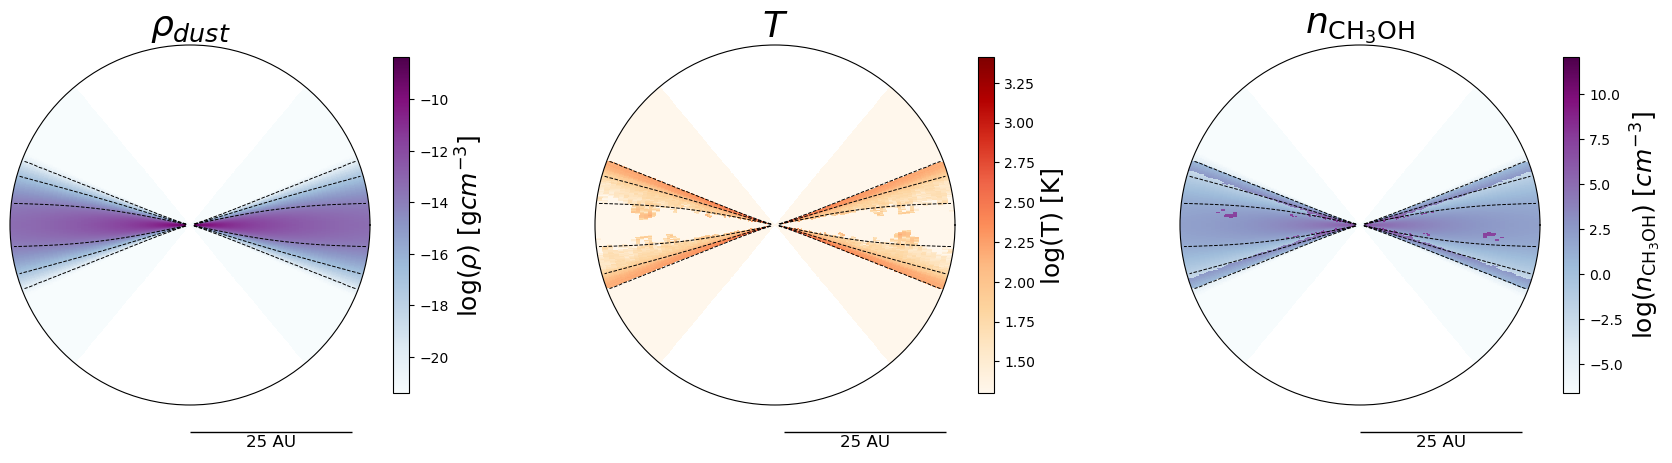

In [22]:
d_best, grid = read_from_dir("./disk_best_irr_mdot_1e-8/")
plot_profile(d_best, grid)

In [23]:
os.chdir("./disk_best_irr_mdot_1e-8/")
os.system("radmc3d image npix 500 sizeau 80 incl 70 lambda 1300 posang -45 noline nphot_scat 200000")
os.chdir("..")

  
      WELCOME TO RADMC-3D: A 3-D CONTINUUM AND LINE RT SOLVER    
                                                                 
                          VERSION 2.0                            
                                                                 
                (c) 2008-2023 Cornelis Dullemond                 
                                                                 
       Please feel free to ask questions. Also please report     
        bugs and/or suspicious behavior without hestitation.     
      The reliability of this code depends on your vigilance!    
                    dullemond@uni-heidelberg.de                  
                                                                 
   To keep up-to-date with bug-alarms and bugfixes, follow the   
                     RADMC-3D code on github                     
             https://github.com/dullemond/radmc3d-2.0            
                                                                 
       

Reading ./disk_best_irr_mdot_1e-8/image.out


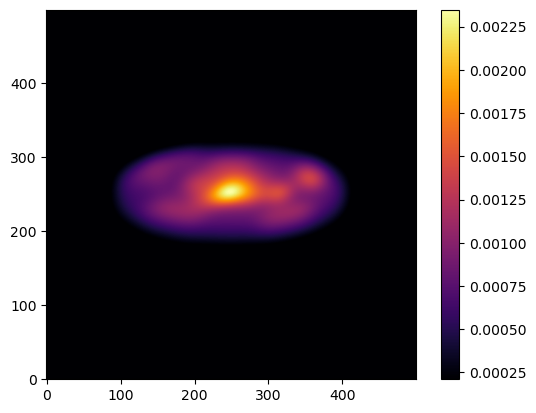

In [24]:
im = image.readImage(fname=f'./disk_best_irr_mdot_1e-8/image.out')
im_conv = im.imConv(dpc=140, fwhm=beam_axis, pa=-69.4)

im_conv = rotate_image(im_conv, 45)

im_conv *= beam_area/pixel_area/(140**2)
plt.imshow(im_conv.T, origin='lower', cmap="inferno", vmin=10*21e-6)
plt.colorbar()


In [25]:
plt.close("all")

In [26]:
i_r_model = get_radial_profile(im, beam_axis, posang=45, center=None, width=10)
plot_i_r(i_r_model, a, L_star, Q, mdot, heat='radiation')


In [27]:
plt.close("all")

In [28]:
im = image.readImage(fname=f'./test/outfile/conti_a_{0.01}_Lstar_{5.0}_Q_{1.5}_mdot_{1e-7}_radiation_scat.out')
im_conv = im.imConv(dpc=140, fwhm=beam_axis, pa=-69.4)


im_conv = rotate_image(im_conv, 0)

im_conv *= beam_area/pixel_area/(140**2)

Reading ./test/outfile/conti_a_0.01_Lstar_5.0_Q_1.5_mdot_1e-07_radiation_scat.out
